## SORRM Preliminary Analysis

In [2]:
#Packages 
import numpy as np
import xarray as xr
import cmocean.cm as cmo
import matplotlib.pyplot as plt
import mosaic
from xgcm import Grid
from datetime import datetime

In [3]:
def rename_time_avg_vars(avg_ds_output):
    old_name_array = []
    new_name_array = []
    
    for i in avg_ds_output.data_vars:
        old_name_array.append(i)
        if 'timeMonthly' in i:
            new_name = i.replace('timeMonthly_avg_' , '')
            if 'Tracer' in new_name:
                new_name = new_name.split('_')[1]
        else:
            new_name = i                
        new_name_array.append(new_name)
    
    new_name_dict = dict(zip(old_name_array, new_name_array))

    return new_name_dict

In [4]:
# OPEN MESH & DS_OUTPUT FILES, FORMAT

# mesh
mesh_filepath = '/global/cfs/cdirs/e3sm/inputdata/ocn/mpas-o/oQU240/' 
# taken from /pscratch/sd/k/kuyeda/e3sm_scratch/pm-cpu/QU240_GMPASO-JRA-DVD_tests/Buildconf/mpasoconf/mpaso_in file(which is like a namelist, I guess
mesh_name = 'ocean.QU.240km.151209.nc'
mesh = xr.open_dataset(mesh_filepath + mesh_name)
# set up descriptor for plotting 
# # set up mesh to apply polypcolor
mesh.attrs['is_periodic'] = 'YES'
mesh.attrs['x_period'] = 360
mesh.attrs['y_period'] = 0.0

descriptor = mosaic.Descriptor(mesh,use_latlon=False)
descriptor = mosaic.Descriptor(mesh, use_latlon=False)

#avg_ds_output
filepath = '/pscratch/sd/k/kuyeda/e3sm_scratch/pm-cpu/QU240_GMPASO-JRA-DVD_tests/run/'
filename = 'QU240_GMPASO-JRA-DVD_tests.mpaso.hist.am.timeSeriesStatsMonthly.*'
avg_ds_output = xr.open_mfdataset(filepath + filename, decode_times= False, chunks={'Time' : 6, 'nCells' : 7153, 'nVertLevels' : 60})

drop_var_names = ['avgValue', 'Stats', 'min', 'max']

dropped_vars = [
    item for item in list(avg_ds_output.data_vars)
    if any(var_name in item for var_name in drop_var_names)
]

avg_ds_output = avg_ds_output.drop_vars(dropped_vars)
new_name_dict = rename_time_avg_vars(avg_ds_output)
avg_ds_output = avg_ds_output.rename(new_name_dict)


In [5]:
avg_ds_output.salinity

<xarray.DataArray 'salinity' (Time: 6, nCells: 7153, nVertLevels: 60)> Size: 10MB
dask.array<concatenate, shape=(6, 7153, 60), dtype=float32, chunksize=(1, 7153, 60), chunktype=numpy.ndarray>
Coordinates:
  * Time     (Time) float32 24B 15.56 45.0 74.5 105.0 135.5 166.0
Dimensions without coordinates: nCells, nVertLevels
Attributes:
    long_name:           salinity in grams salt per kilogram seawater
    units:               1.e-3
    missing_value_mask:  cellMask

In [6]:
# not really sure why there an open_mfdataset doesn't work for this one...
a = xr.open_dataset(filepath + 'QU240_GMPASO-JRA-DVD_tests.mpaso.hist.0001-02-01_00000.nc')
b = xr.open_dataset(filepath + 'QU240_GMPASO-JRA-DVD_tests.mpaso.hist.0001-03-01_00000.nc')
c = xr.open_dataset(filepath + 'QU240_GMPASO-JRA-DVD_tests.mpaso.hist.0001-04-01_00000.nc')
d = xr.open_dataset(filepath + 'QU240_GMPASO-JRA-DVD_tests.mpaso.hist.0001-05-01_00000.nc')
e = xr.open_dataset(filepath + 'QU240_GMPASO-JRA-DVD_tests.mpaso.hist.0001-06-01_00000.nc')
f = xr.open_dataset(filepath + 'QU240_GMPASO-JRA-DVD_tests.mpaso.hist.0001-07-01_00000.nc')

ss_ds_output = xr.concat([a, b, c, d, e, f], dim='Time')

In [7]:
sim_res = '240km'
# interpolate / add info needed to make calculations
# interpolate the DVD vertical physical mixing onto nVertLevels
avg_ds_grid = Grid(avg_ds_output, coords={'Z' : {'center' : 'nVertLevels', 'outer' : 'nVertLevelsP1'}},
                   padding = 'extend', 
                   autoparse_metadata = False)
avg_ds_output['chiPhyVerTemp_center'] = avg_ds_grid.interp(avg_ds_output.chiPhyVerTemp, 'Z' , padding = 'extend')
avg_ds_output['chiPhyVerSalt_center'] = avg_ds_grid.interp(avg_ds_output.chiPhyVerSalt, 'Z', padding = 'extend')
avg_ds_output['vertDiff_center'] = avg_ds_grid.interp(avg_ds_output.vertDiffTopOfCell, 'Z', padding = 'extend')

# interpolate salinity onto nVertLevelsP1
# ffill (good practice but not applicable here because no bathymetry)
avg_ds_output['salinity'] = avg_ds_output.salinity.ffill(dim= 'nVertLevels', limit = 2)
avg_ds_output['salinity'] = avg_ds_output.salinity.bfill(dim= 'nVertLevels', limit = 2)

avg_ds_output['salinity_P1'] = avg_ds_grid.interp(avg_ds_output.salinity, 'Z', padding = 'extend')


# snapshots at every timestep (dt = ? mins)
# ss_ds_output = xr.open_dataset(filepath + f'{sim_res}_channel_output.nc' + suffix,decode_times=False)

# assign nVertLevelsP1 coordinates
ss_ds_output = ss_ds_output.assign_coords({'nVertLevelsP1' : avg_ds_output.nVertLevelsP1})

# interpolate salinity onto nVertLevelsP1
ss_ds_grid = Grid(ss_ds_output, coords={'Z' : {'center' : 'nVertLevels', 'outer' : 'nVertLevelsP1'}},
                   padding = 'extend', 
                   autoparse_metadata = False)

# ffill (good practice but not applicable here because no bathymetry)
ss_ds_output['salinity'] = ss_ds_output.salinity.ffill(dim= 'nVertLevels', limit = 2)
ss_ds_output['salinity'] = ss_ds_output.salinity.bfill(dim= 'nVertLevels', limit = 2)

ss_ds_output['salinity_P1'] = ss_ds_grid.interp(ss_ds_output.salinity, 'Z', padding = 'extend')

In [8]:
for i in avg_ds_output.data_vars:
    if 'Spur' in i:
        print(i)

chiSpurTempBR08
chiSpurSaltBR08


In [9]:
for i in avg_ds_output.data_vars:
    if 'Tendency' in i:
        print(i)

frazilLayerThicknessTendency
frazilTemperatureTendency
temperatureHorizontalAdvectionTendency
salinityHorizontalAdvectionTendency
temperatureVerticalAdvectionTendency
salinityVerticalAdvectionTendency
temperatureVertMixTendency
salinityVertMixTendency
temperatureHorMixTendency
salinityHorMixTendency
temperatureSurfaceFluxTendency
salinitySurfaceFluxTendency
temperatureShortWaveTendency
temperatureNonLocalTendency
salinityNonLocalTendency


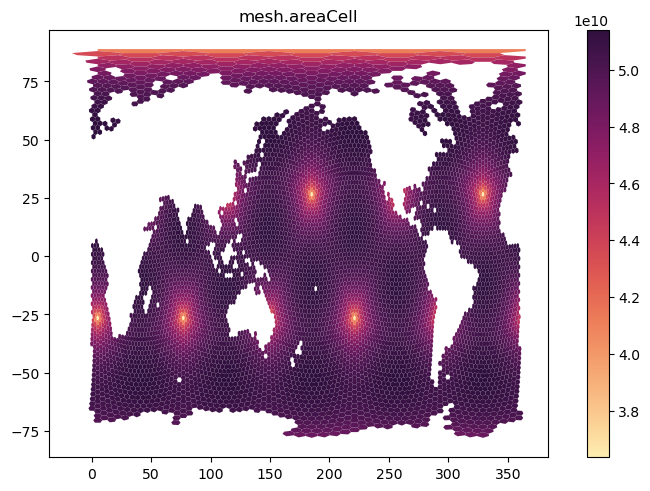

In [10]:
fig, ax = plt.subplots(nrows=1, ncols=1, constrained_layout=True)

a = mosaic.polypcolor(ax, descriptor, mesh.areaCell, cmap='cmo.matter')

ax.set_title('mesh.areaCell')
fig.colorbar(a, ax=ax)

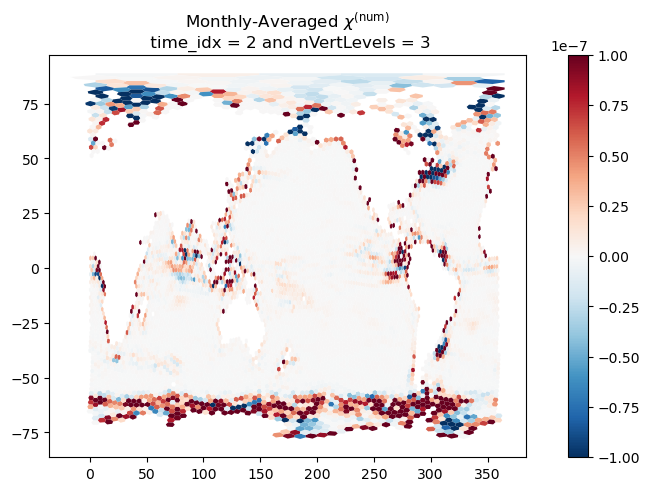

In [11]:
fig, ax = plt.subplots(nrows=1, ncols=1, constrained_layout=True)

time_idx = 2
nVertLevels_idx = 3
vmax_val = 1e-7
vmin_val = -vmax_val

a = mosaic.polypcolor(ax, descriptor, avg_ds_output.chiSpurSaltBR08.isel(Time=time_idx, nVertLevels =3), vmin = vmin_val, vmax = vmax_val, cmap='RdBu_r')

ax.set_title(r'Monthly-Averaged $\chi^{\text{(num)}}$' + '\n time_idx = ' + f'{time_idx} and nVertLevels = {nVertLevels_idx}')
fig.colorbar(a, ax=ax)

In [12]:
# write function to calculate G_F_phy
def calculate_G_F_phy(F_variable, rho_0, mesh, ds_output, target_coord_spacing = 1):
    # rho_0 = 1026
    # F_variable = 'salinityVertMixTendency'
    # target_coord_spacing = 1
    
    # calculate the integrand
    dV = (mesh.areaCell * ds_output.layerThickness)
    tendency = rho_0 * ds_output[F_variable] * dV
    
    # Remap to salinity coordinates
    # to conservatively remap with xgcm:
    # >- datavariables must sit on cell centers
    # >- must supply cell edges to calculate remap
    # >- datavariable will be transformed onto cell center
    # So we must
    # >- ensure datavariable sits on salinity to begin with
    # >- supply outer (P1) coordinate for the transformation
    # >- transform such that the datavariable sits on salinity and not nVertLevels
    
    # set up salinity data to be target coords
    # not for this set up, but good practice in case there's topography
    # fill the bottom cell with the same value as the one above it (so it is no longer a nan)
    # ds_output['salinity'] = ds_output.salinity.ffill(dim= 'nVertLevels', limit = 1)
    
    # calculate target salinity coordinates (salinity_P1)
    # interpolate salinity onto nVertLevelsP1, then use those values to inform target_coords as salinity_P1
    grid_nVertLevels = Grid(ds_output, coords={'Z' : {'center' : 'nVertLevels', 'outer' : 'nVertLevelsP1'}}, 
                            padding = 'extend', 
                            autoparse_metadata=False)
    
    ds_output['salinity_P1'] = grid_nVertLevels.interp(ds_output.salinity, 'Z', padding = 'extend')
    
    # +2 to ensure that the upper and lower bins have a Gphy = 0
    # lower_bound = ds_output.salinity_P1.isel(Time=0, nVertLevelsP1=0).min() - 2
    # upper_bound = ds_output.salinity_P1.isel(Time=0, nVertLevelsP1=0).max() + 2
    
    lower_bound = ds_output.salinity_P1.min() - (3 * target_coord_spacing)
    upper_bound = ds_output.salinity_P1.max() + (3 * target_coord_spacing)
    
    target_coords_P1 = np.arange(lower_bound,upper_bound,target_coord_spacing)
    dlambda = target_coords_P1[0] - target_coords_P1[1] # dlambda < 0 because we are taking i - i+1
    
    # we know that target_coords_P1 is evenly spaced, so taking an average is easy
    target_coords = (target_coords_P1[1:] + target_coords_P1[:-1]) / 2
    salinity_trimmed = target_coords[1:-1]
    
    # transform integrand onto salinity coordinates
    da_F_tendency_transformed = grid_nVertLevels.transform(tendency, # data we want to transform (on cell centers)
                                                           'Z', # axis of transformation
                                                           target_coords_P1, # salinity_P1 coordinates we use to get the salinity coords we remap to
                                                           method = 'conservative', # method
                                                           target_data = ds_output.salinity_P1) # actual salinity values to that need to be binned
    
    # rename (should be on salinity coords)
    ds_F_tendency_transformed = da_F_tendency_transformed.to_dataset(name = 'tendency_' + F_variable).rename({'salinity_P1' : 'salinity'})
    
    ds_F_tendency_transformed['salinity_P1'] = target_coords_P1
    
    salinity_grid = Grid(ds_F_tendency_transformed, coords={'Z' : {'center' : 'salinity', 'outer' : 'salinity_P1'}},
                            padding = 'extend',
                            autoparse_metadata = False)
    
    # reverse cumsum (now sits on salinity_P1)
    da_F_volume_int_tendency_transformed = salinity_grid.cumsum(ds_F_tendency_transformed['tendency_' + F_variable],
                                                                'Z',
                                                                to = 'outer',
                                                                reverse=True)
    
    # convert from dataarray to dataset
    ds_F_volume_int_tendency_transformed = da_F_volume_int_tendency_transformed.to_dataset(name = 'cumulative_vol_int_tendency_' + F_variable)
    ds_F_volume_int_tendency_transformed['salinity'] = target_coords
    
    # remap back onto salinity coordinates
    ds_F_volume_int_tendency_transformed_salinity = salinity_grid.interp(ds_F_volume_int_tendency_transformed['cumulative_vol_int_tendency_' + F_variable],
                                                                          'Z',
                                                                          padding='extend').to_dataset(name = 'cumulative_vol_int_tendency_' + F_variable)
    
    # calculate the derivative of the integrand
    # create array
    G_F_phy = []
    
    # taking the difference remaps from salinity coords to salinity_P1 coords
    for i in range(0,len(target_coords)-1):
        d_tracerMassFlux = ds_F_volume_int_tendency_transformed_salinity['cumulative_vol_int_tendency_' + F_variable][:,:,i] - ds_F_volume_int_tendency_transformed_salinity[
                                                                         'cumulative_vol_int_tendency_' + F_variable][:,:,i+1]
        d_tracerMassFlux_dlambda = - (d_tracerMassFlux / dlambda)
        G_F_phy.append(d_tracerMassFlux_dlambda)
    
    # note that the first and last values of the G_F_phy salinity_P1 levels should be zero
    salinity_P1_trimmed = target_coords_P1[1:-1]
    
    G_F_phy_ds = (xr.concat(G_F_phy, dim = 'salinity_P1').assign_coords(salinity_P1 = salinity_P1_trimmed)).to_dataset(name='G_F_phy')
    G_F_phy_ds['salinity'] = target_coords[1:-1]
    
    # remap back onto salinity coordinates
    # make a new grid that has the trimmed cordinates
    salinity_grid_trimmed = Grid(G_F_phy_ds, coords={'Z' : {'center' : 'salinity', 'outer' : 'salinity_P1'}},
                               padding = 'extend',
                               autoparse_metadata= False)
    
    G_F_phy_ds['G_F_phy_center'] = salinity_grid_trimmed.interp(G_F_phy_ds.G_F_phy, 'Z', padding='extend')
    
    G_F_phy_ds = xr.merge([G_F_phy_ds, ds_F_tendency_transformed])
    
    return G_F_phy_ds

In [202]:
## CHUNKING ATTEMPT

#avg_ds_output
filepath = '/pscratch/sd/k/kuyeda/e3sm_scratch/pm-cpu/QU240_GMPASO-JRA-DVD_tests/run/'
filename = 'QU240_GMPASO-JRA-DVD_tests.mpaso.hist.am.timeSeriesStatsMonthly.*'
avg_ds_output = xr.open_mfdataset(filepath + filename, decode_times= False)
# avg_ds_output = avg_ds_output.chunk({'Time' : 6, 'nCells' : 7153, 'nVertLevels' : 60})

drop_var_names = ['avgValue', 'Stats', 'min', 'max']

dropped_vars = [
    item for item in list(avg_ds_output.data_vars)
    if any(var_name in item for var_name in drop_var_names)
]

avg_ds_output = avg_ds_output.drop_vars(dropped_vars)
new_name_dict = rename_time_avg_vars(avg_ds_output)
avg_ds_output = avg_ds_output.rename(new_name_dict)

sim_res = '240km'
# interpolate / add info needed to make calculations
# interpolate the DVD vertical physical mixing onto nVertLevels
avg_ds_grid = Grid(avg_ds_output, coords={'Z' : {'center' : 'nVertLevels', 'outer' : 'nVertLevelsP1'}},
                   padding = 'extend', 
                   autoparse_metadata = False)
avg_ds_output['chiPhyVerTemp_center'] = avg_ds_grid.interp(avg_ds_output.chiPhyVerTemp, 'Z' , padding = 'extend')
avg_ds_output['chiPhyVerSalt_center'] = avg_ds_grid.interp(avg_ds_output.chiPhyVerSalt, 'Z', padding = 'extend')
avg_ds_output['vertDiff_center'] = avg_ds_grid.interp(avg_ds_output.vertDiffTopOfCell, 'Z', padding = 'extend')

# interpolate salinity onto nVertLevelsP1
# ffill (good practice but not applicable here because no bathymetry)
avg_ds_output['salinity'] = avg_ds_output.salinity.ffill(dim= 'nVertLevels', limit = 2)
avg_ds_output['salinity'] = avg_ds_output.salinity.bfill(dim= 'nVertLevels', limit = 2)

avg_ds_output['salinity_P1'] = avg_ds_grid.interp(avg_ds_output.salinity, 'Z', padding = 'extend')


# write function to calculate G_F_phy
# rho_0 = 1026
# F_variable = 'salinityVertMixTendency'
# target_coord_spacing = 1
def calculate_G_F_phy(F_variable, rho_0, mesh, ds_output, target_coord_spacing = 1):
rho_0 = 1026
target_coord_spacing = 0.5
ds_output = avg_ds_output
F_variable = 'salinityVertMixTendency' 

# calculate the integrand
dV = (mesh.areaCell * ds_output.layerThickness)
tendency = rho_0 * ds_output[F_variable] * dV

# Remap to salinity coordinates
# to conservatively remap with xgcm:
# >- datavariables must sit on cell centers
# >- must supply cell edges to calculate remap
# >- datavariable will be transformed onto cell center
# So we must
# >- ensure datavariable sits on salinity to begin with
# >- supply outer (P1) coordinate for the transformation
# >- transform such that the datavariable sits on salinity and not nVertLevels

# set up salinity data to be target coords
# not for this set up, but good practice in case there's topography
# fill the bottom cell with the same value as the one above it (so it is no longer a nan)
# ds_output['salinity'] = ds_output.salinity.ffill(dim= 'nVertLevels', limit = 1)

# calculate target salinity coordinates (salinity_P1)
# interpolate salinity onto nVertLevelsP1, then use those values to inform target_coords as salinity_P1
grid_nVertLevels = Grid(ds_output, coords={'Z' : {'center' : 'nVertLevels', 'outer' : 'nVertLevelsP1'}}, 
                        padding = 'extend', 
                        autoparse_metadata=False)

ds_output['salinity_P1'] = grid_nVertLevels.interp(ds_output.salinity, 'Z', padding = 'extend')

# +2 to ensure that the upper and lower bins have a Gphy = 0
# lower_bound = ds_output.salinity_P1.isel(Time=0, nVertLevelsP1=0).min() - 2
# upper_bound = ds_output.salinity_P1.isel(Time=0, nVertLevelsP1=0).max() + 2

lower_bound = ds_output.salinity_P1.min() - (3 * target_coord_spacing)
upper_bound = ds_output.salinity_P1.max() + (3 * target_coord_spacing)

target_coords_P1 = np.arange(lower_bound,upper_bound,target_coord_spacing)
dlambda = target_coords_P1[0] - target_coords_P1[1] # dlambda < 0 because we are taking i - i+1

# we know that target_coords_P1 is evenly spaced, so taking an average is easy
target_coords = (target_coords_P1[1:] + target_coords_P1[:-1]) / 2
salinity_trimmed = target_coords[1:-1]

# transform integrand onto salinity coordinates
da_F_tendency_transformed = grid_nVertLevels.transform(tendency, # data we want to transform (on cell centers)
                                                       'Z', # axis of transformation
                                                       target_coords_P1, # salinity_P1 coordinates we use to get the salinity coords we remap to
                                                       method = 'conservative', # method
                                                       target_data = ds_output.salinity_P1) # actual salinity values to that need to be binned

# rename (should be on salinity coords)
ds_F_tendency_transformed = da_F_tendency_transformed.to_dataset(name = 'tendency_' + F_variable).rename({'salinity_P1' : 'salinity'})

ds_F_tendency_transformed['salinity_P1'] = target_coords_P1

salinity_grid = Grid(ds_F_tendency_transformed, coords={'Z' : {'center' : 'salinity', 'outer' : 'salinity_P1'}},
                        padding = 'extend',
                        autoparse_metadata = False)

# reverse cumsum (now sits on salinity_P1)
da_F_volume_int_tendency_transformed = salinity_grid.cumsum(ds_F_tendency_transformed['tendency_' + F_variable],
                                                            'Z',
                                                            to = 'outer',
                                                            reverse=True)

# convert from dataarray to dataset
ds_F_volume_int_tendency_transformed = da_F_volume_int_tendency_transformed.to_dataset(name = 'cumulative_vol_int_tendency_' + F_variable)
ds_F_volume_int_tendency_transformed['salinity'] = target_coords

# remap back onto salinity coordinates
# ds_F_volume_int_tendency_transformed_salinity = salinity_grid.interp(ds_F_volume_int_tendency_transformed['cumulative_vol_int_tendency_' + F_variable],
#                                                                       'Z',
#                                                                       padding='extend').to_dataset(name = 'cumulative_vol_int_tendency_' + F_variable)

ds_F_volume_int_tendency_transformed_salinity = salinity_grid.interp(ds_F_volume_int_tendency_transformed.cumulative_vol_int_tendency_salinityVertMixTendency.chunk({'Time' : 6, 'nCells' : 7153, 'salinity_P1' : 65}),
                                                                     'Z',
                                                                     padding = 'extend').to_dataset(name = 'cumulative_vol_int_tendency_' + F_variable).transpose('Time','nCells','salinity')

# calculate the derivative of the integrand
# create array
G_F_phy = []

# taking the difference remaps from salinity coords to salinity_P1 coords
for i in range(0,len(target_coords)-1):
    d_tracerMassFlux = ds_F_volume_int_tendency_transformed_salinity['cumulative_vol_int_tendency_' + F_variable][:,:,i] - ds_F_volume_int_tendency_transformed_salinity[
                                                                     'cumulative_vol_int_tendency_' + F_variable][:,:,i+1]
    d_tracerMassFlux_dlambda = - (d_tracerMassFlux / dlambda)
    G_F_phy.append(d_tracerMassFlux_dlambda)

# note that the first and last values of the G_F_phy salinity_P1 levels should be zero
salinity_P1_trimmed = target_coords_P1[1:-1]

G_F_phy_ds = (xr.concat(G_F_phy, dim = 'salinity_P1').assign_coords(salinity_P1 = salinity_P1_trimmed)).to_dataset(name='G_F_phy')
G_F_phy_ds['salinity'] = target_coords[1:-1]

# remap back onto salinity coordinates
# make a new grid that has the trimmed cordinates
salinity_grid_trimmed = Grid(G_F_phy_ds, coords={'Z' : {'center' : 'salinity', 'outer' : 'salinity_P1'}},
                           padding = 'extend',
                           autoparse_metadata= False)

G_F_phy_ds['G_F_phy_center'] = salinity_grid_trimmed.interp(G_F_phy_ds.G_F_phy.chunk({'salinity_P1' : 63, 'Time' : 6, 'nCells' : 7153}), 
                                                            'Z', padding='extend')

G_F_phy_ds = xr.merge([G_F_phy_ds, ds_F_tendency_transformed])

return G_F_phy_ds


In [13]:
# NEW
def calculate_G_chi_mix(chi_variable, rho_0, mesh, ds_output, target_coord_spacing):
    # rho_0 = 1026
    # target_coord_spacing = 1
    # # your chi_variable should sit on cell centers
    # chi_variable = 'chiPhyVerSalt_center'
    # ds_output = avg_ds_output
    
    if 'BR08' in chi_variable:
        mixing_type = 'num'
        print(r'Calculating G_chi_num')
    if 'Phy' in chi_variable:
        mixing_type = 'phy'
        print(r'Calculating G_chi_phy')
    
    # calculate the integrand
    dV = mesh.areaCell * ds_output.layerThickness
    mixing = rho_0 * ds_output[chi_variable] * dV
    
    # set target coordinate bins
    lower_bound = ds_output.salinity_P1.min() - (3 * target_coord_spacing)
    upper_bound = ds_output.salinity_P1.max() + (3 * target_coord_spacing)
    
    target_coords_P1 = np.arange(lower_bound,upper_bound,target_coord_spacing)
    
    d_lambda = target_coords_P1[0] - target_coords_P1[1] # d_lambda < 0 b/c we are taking the derivative as i --> 0 so i - i+1
    salinity_P1_trimmed = target_coords_P1[1:-1] # finite difference eliminates first and last values of array
    
    # we know that target_coords_P1 is evenly spaced, so taking an average is easy
    target_coords = (target_coords_P1[1:] + target_coords_P1[:-1]) / 2
    salinity_trimmed = target_coords[1:-1] # second finite difference eliminates first and last values of array
    
    # create a grid to transform mixing from nVertLevels to salinity coords
    grid = Grid(ds_output, coords = {'Z' : {'center' : 'nVertLevels' , 'outer' : 'nVertLevelsP1'}},
                padding = 'extend',
                autoparse_metadata = False)
    
    # transform
    mixing_salinity = grid.transform(mixing, # currently sitting on cell centers
                                     'Z',
                                     target_coords_P1, # conservative remap requires specifying target edge coords
                                     method = 'conservative',
                                     target_data = ds_output.salinity_P1) # corresponding actual coords to be binned in target_coords
    
    # rename coords (still on salinity) and convert to dataset
    mixing_salinity = mixing_salinity.to_dataset(name = 'mixing_per_salinity_cell').rename({'salinity_P1' : 'salinity'})
    
    # add back salinity_P1 coords
    mixing_salinity['salinity_P1'] = target_coords_P1
    
    # sum over each layer to get the mixing per salinity class
    # create a salinity coord grid
    salinity_grid = Grid(mixing_salinity, coords = {'Z' : {'center' : 'salinity', 'outer' : 'salinity_P1'}},
                         padding = 'extend',
                         autoparse_metadata = False)
    
    # reverse cumsum. remaps from salinity to salinity_P1 coords
    cumulative_mixing = salinity_grid.cumsum(mixing_salinity.mixing_per_salinity_cell,
                                                     'Z',
                                                     to = 'outer',
                                                     reverse=True).to_dataset(name = 'cumulative_' + mixing_type + '_mixing')
    # add back salinity_P1 coords
    cumulative_mixing['salinity_P1'] = target_coords_P1
    
    # interpolate back onto salinity coords, order coords
    cumulative_mixing_salinity = salinity_grid.interp(cumulative_mixing['cumulative_' + mixing_type + '_mixing'],
                                                      'Z',
                                                      padding = 'extend').transpose('salinity', 'nCells', 'Time')#.to_dataset(name =  'cumulative_' + mixing_type + '_mixing')
    
    
    # calculate the first derivative (mixing per salinity class) 
    # taking a difference will put values back onto salinity_P1 coords
    mixingPerSalinityClass = []
    
    # take the first deriv (from salinity coords to salinity_P1 coords) with i = i+1
    # requires coords to be ordered as (salinity, nCells, Time)
    
    for i in range(0,len(target_coords)-1):
        d_mixing = cumulative_mixing_salinity[i, :, :] - cumulative_mixing_salinity[i+1, :,:]
        d_mixing_d_lambda = d_mixing / d_lambda # mixing per salinity class
        mixingPerSalinityClass.append(d_mixing_d_lambda)
    
    # convert mixingPerSalinityClass to dataarray
    mixingPerSalinityClass_da = xr.concat(mixingPerSalinityClass, dim = 'salinity')
    
    # take the second derivative (from salinity_P1 coords back to salinity coords)
    # again, by taking the differrence, you will lose the first and last entries of the salinity coords
    # this derivative calculates the convergence of the mixing flux
    
    G_chi_mix = []
    
    for i in range(0,len(target_coords)-2):
        d_mixingFlux = mixingPerSalinityClass_da[i,:,:] - mixingPerSalinityClass_da[i+1,:,:]
        conv_mixingFlux = d_mixingFlux / d_lambda
        G_chi_mix.append(conv_mixingFlux * -0.5) # by definition, G_chi_mix is multiplied by -1/2
    
    # convert G_chi_mix to dataset
    G_chi_mix_ds = (xr.concat(G_chi_mix, dim= 'salinity').assign_coords(salinity = salinity_trimmed)).to_dataset(name='G_chi_' + mixing_type)
    
    # add back the salinity_P1 coordinates
    G_chi_mix_ds = G_chi_mix_ds.assign_coords({'salinity_P1' : salinity_P1_trimmed})
    
    return G_chi_mix_ds

In [14]:
def calculate_dt(avg_ds_output):

    time_format = '%Y-%m-%d_%H:%M:%S'
    t0 = datetime.strptime(avg_ds_output.xtime[0].item().decode(), time_format)
    t1 = datetime.strptime(avg_ds_output.xtime[1].item().decode(), time_format)
    
    dt = (t1 - t0).total_seconds()
    return dt

In [15]:
def calculate_dM_dt(rho_0, mesh, avg_ds_output, ss_ds_output, target_coord_spacing):
    # target_coord_spacing = 1
    lower_bound = avg_ds_output.salinity_P1.min() - (3 * target_coord_spacing)
    upper_bound = avg_ds_output.salinity_P1.max() + (3 * target_coord_spacing)
    target_coords_P1 = np.arange(lower_bound,upper_bound,target_coord_spacing)
    target_coords = (target_coords_P1[1:] + target_coords_P1[:-1]) / 2
    
    mass = rho_0 * ss_ds_output.layerThickness * mesh.areaCell
    
    ss_ds_grid = Grid(ss_ds_output, coords = {'Z' : {'center' : 'nVertLevels', 'outer' : 'nVertLevelsP1'}},
                      padding = 'extend',
                      autoparse_metadata = False)
    
    mass_transform = ss_ds_grid.transform(mass, 
                                'Z',
                                target_coords_P1,
                                method = 'conservative',
                                target_data = ss_ds_output.salinity_P1).fillna(0)
    
    mass_transform = mass_transform.rename({'salinity_P1' : 'salinity'})
    
    mass_transform_ds = mass_transform.to_dataset(name='mass_transform')
    mass_transform_ds['salinity_P1'] = target_coords_P1
    mass_transform_ds = mass_transform_ds.set_coords({'salinity_P1' : target_coords_P1})
    
    salinity_grid = Grid(mass_transform_ds, coords={'Z' : {'center' : 'salinity', 'outer' : 'salinity_P1'}},
                         padding = 'extend',
                         autoparse_metadata = False)
    
    mass_vint_salinity_P1 = salinity_grid.cumsum(mass_transform_ds.mass_transform, 
                                                 'Z',
                                                 to = 'outer',
                                                 reverse = True)
    mass_vint_salinity = salinity_grid.interp(mass_vint_salinity_P1, 
                                              'Z',
                                              padding = 'extend').transpose('Time','nCells','salinity')
    
    dM = mass_vint_salinity.diff('Time') 
    dt = calculate_dt(ss_ds_output)
    
    dM_dt = (dM / dt).transpose('salinity', 'nCells', 'Time').to_dataset(name='dM_dt')
    
    return mass, mass_transform, dM_dt

In [16]:
def calculate_G_F_num(dM_dt, G_F_phy_ds):
    G_F_num = (dM_dt.dM_dt - G_F_phy_ds.G_F_phy_center).transpose('salinity','nCells','Time')
    G_F_num_ds = G_F_num.to_dataset(name = 'G_F_num')
    return G_F_num_ds

In [17]:
# wrapper function to perform all calculations
def calculate_budget(rho_0, mesh, ds_output, target_coord_spacing = 1):
    print('Calculating G_F_phy')
    G_F_phy_ds = calculate_G_F_phy('salinityVertMixTendency', rho_0, mesh, avg_ds_output,target_coord_spacing)
    
    G_chi_phy_ds = calculate_G_chi_mix('chiPhyVerSalt_center',rho_0, mesh, avg_ds_output,target_coord_spacing)
    
    G_chi_num_ds = calculate_G_chi_mix('chiSpurSaltBR08',rho_0, mesh, avg_ds_output,target_coord_spacing)

    print('Calculating dM/dt')
    mass, mass_transform, dM_dt_ds = calculate_dM_dt(rho_0, mesh, avg_ds_output, ss_ds_output, target_coord_spacing)
    
    print('Calculating G_F_num')
    G_F_num_ds = calculate_G_F_num(dM_dt_ds, G_F_phy_ds)
    
    # combine the G_phy_ds and G_phy_chi_ds datasets
    budget_ds = xr.merge([G_F_phy_ds.G_F_phy.transpose('salinity_P1', 'nCells', 'Time'), 
                              G_F_phy_ds.G_F_phy_center.transpose('salinity', 'nCells', 'Time'), 
                              G_chi_phy_ds,
                              G_chi_num_ds,
                              dM_dt_ds,
                              G_F_num_ds,
                              avg_ds_output.xtime])

    return G_F_phy_ds, G_chi_phy_ds, G_chi_num_ds, dM_dt_ds, G_F_num_ds, budget_ds

In [190]:
# #avg_ds_output
# filepath = '/pscratch/sd/k/kuyeda/e3sm_scratch/pm-cpu/QU240_GMPASO-JRA-DVD_tests/run/'
# filename = 'QU240_GMPASO-JRA-DVD_tests.mpaso.hist.am.timeSeriesStatsMonthly.*'
# avg_ds_output = xr.open_mfdataset(filepath + filename, decode_times= False, chunks={'Time' : 6, 'nCells' : 7153, 'nVertLevels' : 60})

# drop_var_names = ['avgValue', 'Stats', 'min', 'max']

# dropped_vars = [
#     item for item in list(avg_ds_output.data_vars)
#     if any(var_name in item for var_name in drop_var_names)
# ]

# avg_ds_output = avg_ds_output.drop_vars(dropped_vars)
# new_name_dict = rename_time_avg_vars(avg_ds_output)
# avg_ds_output = avg_ds_output.rename(new_name_dict)




In [18]:
## WORKING FUNCTION
# write function to calculate G_F_phy
# rho_0 = 1026
# F_variable = 'salinityVertMixTendency'
# target_coord_spacing = 1
rho_0 = 1026
target_coord_spacing = 0.5
ds_output = avg_ds_output
F_variable = 'salinityVertMixTendency' 

# calculate the integrand
dV = (mesh.areaCell * ds_output.layerThickness)
tendency = rho_0 * ds_output[F_variable] * dV

# Remap to salinity coordinates
# to conservatively remap with xgcm:
# >- datavariables must sit on cell centers
# >- must supply cell edges to calculate remap
# >- datavariable will be transformed onto cell center
# So we must
# >- ensure datavariable sits on salinity to begin with
# >- supply outer (P1) coordinate for the transformation
# >- transform such that the datavariable sits on salinity and not nVertLevels

# set up salinity data to be target coords
# not for this set up, but good practice in case there's topography
# fill the bottom cell with the same value as the one above it (so it is no longer a nan)
# ds_output['salinity'] = ds_output.salinity.ffill(dim= 'nVertLevels', limit = 1)

# calculate target salinity coordinates (salinity_P1)
# interpolate salinity onto nVertLevelsP1, then use those values to inform target_coords as salinity_P1
grid_nVertLevels = Grid(ds_output, coords={'Z' : {'center' : 'nVertLevels', 'outer' : 'nVertLevelsP1'}}, 
                        padding = 'extend', 
                        autoparse_metadata=False)

ds_output['salinity_P1'] = grid_nVertLevels.interp(ds_output.salinity, 'Z', padding = 'extend')

# +2 to ensure that the upper and lower bins have a Gphy = 0
# lower_bound = ds_output.salinity_P1.isel(Time=0, nVertLevelsP1=0).min() - 2
# upper_bound = ds_output.salinity_P1.isel(Time=0, nVertLevelsP1=0).max() + 2

lower_bound = ds_output.salinity_P1.min() - (3 * target_coord_spacing)
upper_bound = ds_output.salinity_P1.max() + (3 * target_coord_spacing)

target_coords_P1 = np.arange(lower_bound,upper_bound,target_coord_spacing)
dlambda = target_coords_P1[0] - target_coords_P1[1] # dlambda < 0 because we are taking i - i+1

# we know that target_coords_P1 is evenly spaced, so taking an average is easy
target_coords = (target_coords_P1[1:] + target_coords_P1[:-1]) / 2
salinity_trimmed = target_coords[1:-1]

# transform integrand onto salinity coordinates
da_F_tendency_transformed = grid_nVertLevels.transform(tendency, # data we want to transform (on cell centers)
                                                       'Z', # axis of transformation
                                                       target_coords_P1, # salinity_P1 coordinates we use to get the salinity coords we remap to
                                                       method = 'conservative', # method
                                                       target_data = ds_output.salinity_P1) # actual salinity values to that need to be binned

# rename (should be on salinity coords)
ds_F_tendency_transformed = da_F_tendency_transformed.to_dataset(name = 'tendency_' + F_variable).rename({'salinity_P1' : 'salinity'})

ds_F_tendency_transformed['salinity_P1'] = target_coords_P1

salinity_grid = Grid(ds_F_tendency_transformed, coords={'Z' : {'center' : 'salinity', 'outer' : 'salinity_P1'}},
                        padding = 'extend',
                        autoparse_metadata = False)

# reverse cumsum (now sits on salinity_P1)
da_F_volume_int_tendency_transformed = salinity_grid.cumsum(ds_F_tendency_transformed['tendency_' + F_variable],
                                                            'Z',
                                                            to = 'outer',
                                                            reverse=True)

# convert from dataarray to dataset
ds_F_volume_int_tendency_transformed = da_F_volume_int_tendency_transformed.to_dataset(name = 'cumulative_vol_int_tendency_' + F_variable)
ds_F_volume_int_tendency_transformed['salinity'] = target_coords

# remap back onto salinity coordinates
# ds_F_volume_int_tendency_transformed_salinity = salinity_grid.interp(ds_F_volume_int_tendency_transformed['cumulative_vol_int_tendency_' + F_variable],
#                                                                       'Z',
#                                                                       padding='extend').to_dataset(name = 'cumulative_vol_int_tendency_' + F_variable)

ds_F_volume_int_tendency_transformed_salinity = salinity_grid.interp(ds_F_volume_int_tendency_transformed.cumulative_vol_int_tendency_salinityVertMixTendency.chunk({'Time' : 6, 'nCells' : 7153, 'salinity_P1' : 65}),
                                                                     'Z',
                                                                     padding = 'extend').to_dataset(name = 'cumulative_vol_int_tendency_' + F_variable).transpose('Time','nCells','salinity')

# calculate the derivative of the integrand
# create array
G_F_phy = []

# taking the difference remaps from salinity coords to salinity_P1 coords
for i in range(0,len(target_coords)-1):
    d_tracerMassFlux = ds_F_volume_int_tendency_transformed_salinity['cumulative_vol_int_tendency_' + F_variable][:,:,i] - ds_F_volume_int_tendency_transformed_salinity[
                                                                     'cumulative_vol_int_tendency_' + F_variable][:,:,i+1]
    d_tracerMassFlux_dlambda = - (d_tracerMassFlux / dlambda)
    G_F_phy.append(d_tracerMassFlux_dlambda)

# note that the first and last values of the G_F_phy salinity_P1 levels should be zero
salinity_P1_trimmed = target_coords_P1[1:-1]

G_F_phy_ds = (xr.concat(G_F_phy, dim = 'salinity_P1').assign_coords(salinity_P1 = salinity_P1_trimmed)).to_dataset(name='G_F_phy')
G_F_phy_ds['salinity'] = target_coords[1:-1]

# remap back onto salinity coordinates
# make a new grid that has the trimmed cordinates
salinity_grid_trimmed = Grid(G_F_phy_ds, coords={'Z' : {'center' : 'salinity', 'outer' : 'salinity_P1'}},
                           padding = 'extend',
                           autoparse_metadata= False)

G_F_phy_ds['G_F_phy_center'] = salinity_grid_trimmed.interp(G_F_phy_ds.G_F_phy.chunk({'salinity_P1' : 63, 'Time' : 6, 'nCells' : 7153}), 'Z', padding='extend')

G_F_phy_ds = xr.merge([G_F_phy_ds, ds_F_tendency_transformed])


In [188]:
avg_ds_output.salinity

<xarray.DataArray 'salinity' (Time: 6, nCells: 7153, nVertLevels: 60)> Size: 10MB
dask.array<rechunk-merge, shape=(6, 7153, 60), dtype=float32, chunksize=(6, 1, 60), chunktype=numpy.ndarray>
Coordinates:
  * Time     (Time) float32 24B 15.56 45.0 74.5 105.0 135.5 166.0
Dimensions without coordinates: nCells, nVertLevels
Attributes:
    long_name:           salinity in grams salt per kilogram seawater
    units:               1.e-3
    missing_value_mask:  cellMask

In [19]:
# if error with ufunc [innner, outer] or whatever, try looking at your chunk sizes. You may need tor rechunk.

# ds_F_volume_int_tendency_transformed.cumulative_vol_int_tendency_salinityVertMixTendency.chunk({'Time' : 6, 'nCells' : 7153, 'salinity_P1' : 65})
# G_F_phy_ds.G_F_phy.chunk({'salinity_P1' : 63, 'Time' : 6, 'nCells' : 7153})

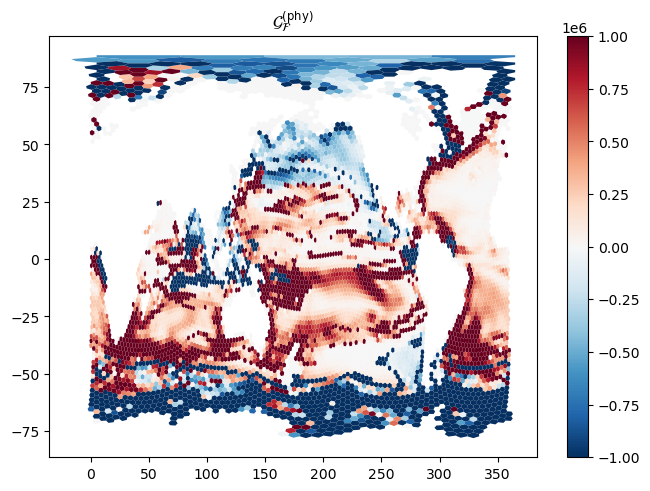

In [166]:
fig, ax = plt.subplots(nrows=1, ncols=1, constrained_layout=True)
vmax_val = 1e9
vmin_val = -vmax_val

a = mosaic.polypcolor(ax, descriptor,(G_F_phy_ds.G_F_phy_center).isel(Time=3, salinity = 55), cmap='RdBu_r',vmin = -1e6, vmax = 1e6)#, vmin = vmin_val, vmax = vmax_val)

ax.set_title(r'$\mathcal{G}_\mathcal{F}^{\text{(phy)}}$')
fig.colorbar(a, ax=ax)

In [ ]:
BRERAAAAK

In [203]:
rho_0 = 1026
target_coord_spacing = 0.5 # 1 # 0.25

mass, mass_transform, dM_dt = calculate_dM_dt(rho_0, mesh, avg_ds_output, ss_ds_output, target_coord_spacing)
G_F_phy_ds, G_chi_phy_ds, G_chi_num_ds, dM_dt_ds, G_F_num_ds, budget_ds = calculate_budget(rho_0, mesh, avg_ds_output, target_coord_spacing)

Calculating G_F_phy


NotImplementedError: Cannot chunk along a core dimension for a grid ufunc which has a signature which includes one of the axis positions ['inner', 'outer'].Consider rechunking to a single chunk along this dimension if possible.